# Chapter 20 — Fatigue and Cyclic Loading
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 20 — Fatigue and Cyclic Loading.

Most structural failures in service do not occur under a single overload — they accumulate slowly, cycle by cycle, from loads well below the static yield strength. Fatigue is the mechanism by which repeated stress cycling initiates and propagates cracks until catastrophic fracture occurs, and it is responsible for the majority of mechanical failures in aircraft, vehicles, and rotating machinery. Understanding fatigue is inseparable from understanding strain measurement, because strain gages are the primary tool for quantifying the cyclic stress history that drives damage accumulation.

This notebook covers two foundational tools of fatigue analysis: the S-N curve (relating stress amplitude to cycles to failure) and Miner's linear damage rule (summing fractional damage across multiple amplitude levels). Together they allow an engineer to predict the remaining life of a component from a measured load spectrum — the output of a strain gage data acquisition campaign.

**This notebook demonstrates:**
1. The S-N curve (Basquin's law) with endurance limit — stress amplitude vs. cycles to failure
2. Miner's rule cumulative damage calculation for a four-level load spectrum

In [1]:
# Colab setup — uncomment to install dependencies:
# !pip install numpy matplotlib

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figure output directory. Do NOT change this path — the book includes these exact files.
OUT_DIR = Path("../src/media/ch20")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
### Shared constants and helper functions

Both sections below rest on the same material model — Basquin's power law, $\sigma_a = \sigma_f'\,(2N_f)^b$ — so we define the material constants and two small helper functions once and reuse them. `basquin_stress` maps a life (in cycles) to the stress amplitude that produces it; `cycles_to_failure` inverts the law to predict life from a measured stress amplitude, which is exactly what a strain gage campaign supplies.

In [2]:
# Material constants for a representative high-strength steel.
SIGMA_F_PRIME = 1000.0      # MPa — fatigue strength coefficient, sigma_f'
B_EXPONENT = -0.1           # fatigue strength (Basquin) exponent, dimensionless
SIGMA_UTS = 700.0           # MPa — ultimate tensile strength
ENDURANCE_FRACTION = 0.5    # endurance limit ~= 0.5 * UTS (common steel rule of thumb)


def basquin_stress(cycles, sigma_f_prime=SIGMA_F_PRIME, b=B_EXPONENT):
    """Stress amplitude (MPa) for a given life, via Basquin's law.

    sigma_a = sigma_f' * (2 * Nf) ** b, where 2*Nf is reversals to failure.
    """
    return sigma_f_prime * (2.0 * cycles) ** b


def cycles_to_failure(sigma_a, sigma_f_prime=SIGMA_F_PRIME, b=B_EXPONENT):
    """Cycles to failure Nf at a stress amplitude, inverting Basquin's law.

    Solving sigma_a = sigma_f' (2 Nf)^b gives Nf = 0.5 * (sigma_a / sigma_f') ** (1 / b).
    """
    return 0.5 * (sigma_a / sigma_f_prime) ** (1.0 / b)

---
## 1 — S-N Curve (Basquin's Law)

The S-N curve plots stress amplitude σ_a against cycles to failure N_f on a log-log scale. Basquin's power law — σ_a = σ'_f (2N_f)^b — fits this relationship with two material constants: the fatigue strength coefficient σ'_f and the fatigue strength exponent b (typically −0.05 to −0.12 for metals). The negative exponent means that lower stress amplitudes produce longer lives; the log-log scale makes this power law appear as a straight line.

For ferrous metals, the S-N curve typically flattens at an *endurance limit* — a stress amplitude below which fatigue damage does not accumulate regardless of cycle count. Non-ferrous metals (aluminum, titanium) do not have a true endurance limit; they continue to fail at lower and lower stresses given enough cycles. The dashed line below shows the conventional endurance limit approximation at 50% of the ultimate tensile strength — a conservative design rule, not a physical law.

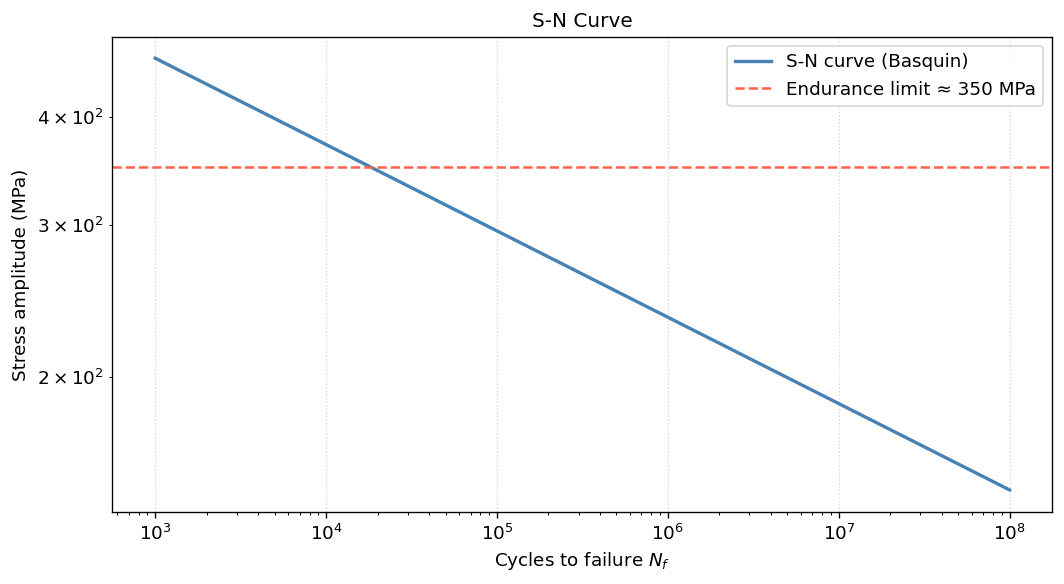

σa = 400 MPa  →  Nf ≈ 4.77e+03 cycles
σa = 300 MPa  →  Nf ≈ 8.47e+04 cycles
σa = 200 MPa  →  Nf ≈ 4.88e+06 cycles


In [3]:
# Sweep a range of lives and read off the stress amplitude each one implies.
Nf = np.logspace(3, 8, 200)                    # cycles to failure, 10^3 ... 10^8
sigma_a = basquin_stress(Nf)                   # MPa
endurance_limit = ENDURANCE_FRACTION * SIGMA_UTS   # MPa

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Nf, sigma_a, 'steelblue', lw=2, label="S-N curve (Basquin)")
ax.axhline(endurance_limit, color='tomato', lw=1.5, linestyle='--',
           label=f"Endurance limit ≈ {endurance_limit:.0f} MPa")
ax.set_xlabel("Cycles to failure $N_f$"); ax.set_ylabel("Stress amplitude (MPa)")
ax.set_title("S-N Curve"); ax.legend(); ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig20_nb1_sn_curve_basquin.png', bbox_inches='tight', dpi=150)
plt.show()

# Invert the law: what life does each measured stress amplitude predict?
for sa in [400, 300, 200]:
    print(f"σa = {sa} MPa  →  Nf ≈ {cycles_to_failure(sa):.2e} cycles")

---
## 2 — Miner's Rule — Cumulative Damage

Palmgren-Miner's rule states that the total fatigue damage D is the sum of fractional damages at each amplitude level: D = Σ(n_i / N_f,i), where n_i is the number of cycles applied at stress amplitude σ_i and N_f,i is the life at that amplitude from the S-N curve. Failure is predicted when D reaches 1.0.

The rule has well-known limitations — it ignores sequence effects, crack closure, and mean stress — but it remains the starting point for any service-life assessment from a measured load spectrum. In practice, strain gages feed load data to a rainflow cycle-counting algorithm, which sorts cycles by amplitude and mean stress; Miner's rule then converts that sorted count into a damage fraction. The table below demonstrates the calculation for a four-level spectrum, showing how most of the damage accumulates at the highest amplitude even though it represents the fewest cycles.

We reuse `cycles_to_failure` from above for every N_f,i, applying Basquin's law at *all* amplitude levels — including those at or below the endurance limit. That is the conservative choice: it credits no infinite-life threshold, so even small cycles contribute a little damage.

In [4]:
# Four-level load spectrum: (stress amplitude in MPa, applied cycles n).
spectrum = [(350, 100), (250, 1000), (180, 10000), (120, 50000)]

total_D = 0.0
print(f"{'σa':>8}  {'n':>8}  {'Nf':>14}  {'n/Nf':>10}  {'D':>10}")
print("-" * 54)
for sigma_a, n in spectrum:
    Nf = cycles_to_failure(sigma_a)
    d = n / Nf
    total_D += d
    print(f"{sigma_a:>8}  {n:>8,}  {Nf:>14.2e}  {d:>10.5f}  {total_D:>10.5f}")

status = "FAILED" if total_D >= 1 else f"{(1 - total_D) * 100:.1f}% life remaining"
print(f"Total D = {total_D:.4f}  ({status})")

      σa         n              Nf        n/Nf           D
------------------------------------------------------
     350       100        1.81e+04     0.00552     0.00552
     250     1,000        5.24e+05     0.00191     0.00742
     180    10,000        1.40e+07     0.00071     0.00814
     120    50,000        8.08e+08     0.00006     0.00820
Total D = 0.0082  (99.2% life remaining)


---
## Where to take this next

- **Add a mean-stress correction.** Real spectra are rarely fully reversed. Apply the Goodman relation from the chapter (Eq. 20.1), $\sigma_a/\sigma_e + \sigma_m/\sigma_{UTS} = 1$, to convert each level's (amplitude, mean) pair into an equivalent fully reversed amplitude *before* calling `cycles_to_failure`, and watch the damage total climb.
- **Enforce a true endurance limit.** Modify `cycles_to_failure` to return infinite life (zero damage) below `endurance_limit`, then re-run Miner's rule. Compare the total against the pure-Basquin result here — the difference is exactly what the "infinite-life" design philosophy buys you.
- **Close the loop with real data.** Replace the hand-written `spectrum` with the output of a rainflow cycle-counting algorithm (Chapter 37) applied to a measured or simulated strain-time history. That is the full pipeline: strain gage → rainflow histogram → S-N curve → Miner's rule → predicted life.